# Oluwafemi S Notebook
# P3: Text Exploration

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Oluwafemi Salawu](https://github.com/Airfirm/)
- Repository: [nlp-03-text-exploration](https://github.com/Airfirm/nlp-03-text-exploration)
- Date: 2026-03

Purpose

  Perform exploratory analysis of a small, controlled text corpus.
  Demonstrate how structure emerges from token distributions,
  category comparisons, co-occurrence patterns, and bigrams.

New Analytical Questions

- Which categories have the highest total number of tokens?
- Which tokens are unique to one category and not shared with others?
- What are the most common bigrams within each category?
- How dense is the vocabulary in each category (unique tokens vs. total tokens)?
- Which context words appear most often around a selected target token?

Notes

- This module focuses on exploratory analysis (EDA), not modeling.
- Results here prepare for later work with pipelines and embeddings.

Project Instructions

- See [docs/project-instructions.md](../docs/project-instructions.md)
- See [docs/glossary.md](../docs/glossary.md)

## Terminology

In preparation for large language models and related methods, our analysis does not begin with semantic interpretation.
Instead, we focus on **proximity** and observable **patterns** in the text.

We evaluate **co-occurrence (context windows)**, 
that is, _which words tend to appear near each other_.

The full collection of text is called a **corpus** (a set of documents).
For this analysis, each document is represented as a single line of text.

See the README.md for more

## Section 1. Setup and Imports

Imports and configuration.

In [1]:
# Section 1 Python cell

from collections import Counter, defaultdict
import logging
from pathlib import Path

from datafun_toolkit.logger import get_logger, log_header, log_path
import matplotlib.pyplot as plt
import polars as pl

print("Imports complete.")

Imports complete.


### Configure Logging

In [2]:
# Section 1 Python cell (logger configuration and path setup)

LOG: logging.Logger = get_logger("CI", level="DEBUG")

NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent
SCRIPTS_PATH: Path = ROOT_PATH / "scripts"

log_header(LOG, "MODULE 3 NOTEBOOK: CORPUS EXPLORATION")

log_path(LOG, "ROOT_PATH", ROOT_PATH)
log_path(LOG, "NOTEBOOKS_PATH", NOTEBOOKS_PATH)
log_path(LOG, "SCRIPTS_PATH", SCRIPTS_PATH)

LOG.info("Logger configured.")

2026-03-20 19:14:19 | INFO | CI | === RUN START ===
2026-03-20 19:14:19 | INFO | CI | project=MODULE 3 NOTEBOOK: CORPUS EXPLORATION
2026-03-20 19:14:19 | INFO | CI | repo_dir=nlp-03-text-exploration
2026-03-20 19:14:19 | INFO | CI | python=3.14.2
2026-03-20 19:14:19 | INFO | CI | os=Windows 11
2026-03-20 19:14:19 | INFO | CI | shell=powershell
2026-03-20 19:14:19 | INFO | CI | cwd=notebooks
2026-03-20 19:14:19 | INFO | CI | github_actions=False
2026-03-20 19:14:19 | INFO | CI | ROOT_PATH = .
2026-03-20 19:14:19 | INFO | CI | NOTEBOOKS_PATH = notebooks
2026-03-20 19:14:19 | INFO | CI | SCRIPTS_PATH = scripts
2026-03-20 19:14:19 | INFO | CI | Logger configured.


## Section 2. Define Corpus (Labeled Text Documents)

In [3]:
# Section 2 Python cell

# A corpus is a collection of text documents.
# Each document is associated with a category label.
# Use a list of dictionaries to represent the corpus in memory.
# A dictionary uses labeled key:value pairs.
# Key:value pairs let us store the category and the text together.

corpus: list[dict[str, str]] = [
    {"category": "dog", "text": "A dog barks loudly."},
    {"category": "dog", "text": "The puppy runs in the yard."},
    {"category": "dog", "text": "A canine wears a leash."},
    {"category": "dog", "text": "The kennel holds the dog."},
    {"category": "dog", "text": "The dog ran across the yard."},
    {"category": "dog", "text": "The puppy ran across the yard."},
    {"category": "cat", "text": "A cat sleeps quietly."},
    {"category": "cat", "text": "The kitten plays with yarn."},
    {"category": "cat", "text": "A feline purrs softly."},
    {"category": "cat", "text": "The cat has whiskers."},
    {"category": "cat", "text": "The cat slept near the window."},
    {"category": "cat", "text": "The kitten slept near the window."},
    {"category": "car", "text": "A car drives on the road."},
    {"category": "car", "text": "The sedan parks in the garage."},
    {"category": "car", "text": "A vehicle has four wheels."},
    {"category": "car", "text": "The car moves down the highway."},
    {"category": "car", "text": "The car stopped near the garage."},
    {"category": "car", "text": "The sedan stopped near the garage."},
    {"category": "truck", "text": "A truck carries cargo."},
    {"category": "truck", "text": "The pickup pulls a trailer."},
    {"category": "truck", "text": "The engine powers the truck."},
    {"category": "truck", "text": "The truck hauls heavy loads."},
]

print(f"Corpus contains {len(corpus)} documents.")

Corpus contains 22 documents.


## Section 3. Tokenize and Clean Text

In [4]:
# Section 3 Python cell

# Tokenization splits text into word-like units.

# Define a function to tokenize text by lowercasing, splitting on whitespace,
# and stripping common punctuation. We also filter out very short tokens (length <= 2).
# This simple tokenizer is sufficient for our small, controlled corpus.
# Use the string strip() method to remove punctuation from the beginning and end of each token.
def tokenize(text: str) -> list[str]:
    tokens = text.lower().split()
    return [
        t.strip(".,:;!?()[]\"'") for t in tokens if len(t.strip(".,:;!?()[]\"'")) > 2
    ]


# Define a new empty list to hold the token records we will create.
records_list: list[dict[str, str]] = []
# Loop through each document, tokenize the text,
# and create a record for each token with its category and
# add it to our list of records.
for doc in corpus:
    # Call our function to tokenize the text of the current document.
    tokens = tokenize(doc["text"])
    # Loop through each token produced by the tokenizer and
    # create a record that includes the category of the document and the token itself.
    # Append this record to our list of records.
    for token in tokens:
        records_list.append({"category": doc["category"], "token": token})

# Create a Polars DataFrame from the list of token records for easier analysis.
token_df: pl.DataFrame = pl.DataFrame(records_list)

# Show results
print("Tokenization complete.")
print(token_df.head(10))

Tokenization complete.
shape: (10, 2)
┌──────────┬────────┐
│ category ┆ token  │
│ ---      ┆ ---    │
│ str      ┆ str    │
╞══════════╪════════╡
│ dog      ┆ dog    │
│ dog      ┆ barks  │
│ dog      ┆ loudly │
│ dog      ┆ the    │
│ dog      ┆ puppy  │
│ dog      ┆ runs   │
│ dog      ┆ the    │
│ dog      ┆ yard   │
│ dog      ┆ canine │
│ dog      ┆ wears  │
└──────────┴────────┘


## Section 4. Compute Global Token Frequencies

In [5]:
# Section 4 Python cell

# Frequency distribution = how often each token appears.

# Create a DataFrame that groups the tokens by their text and
# counts how many times each token appears across the entire corpus.
global_freq_df: pl.DataFrame = (
    token_df.group_by("token").len().sort("len", descending=True)
)

# Show results
print("Top global tokens:")
print(global_freq_df.head(10))

Top global tokens:
shape: (10, 2)
┌────────┬─────┐
│ token  ┆ len │
│ ---    ┆ --- │
│ str    ┆ u32 │
╞════════╪═════╡
│ the    ┆ 27  │
│ near   ┆ 4   │
│ dog    ┆ 3   │
│ car    ┆ 3   │
│ cat    ┆ 3   │
│ yard   ┆ 3   │
│ truck  ┆ 3   │
│ garage ┆ 3   │
│ ran    ┆ 2   │
│ kitten ┆ 2   │
└────────┴─────┘


## Section 5. Compute Token Frequencies by Category

In [6]:
# Section 5 Python cell

# Compare token usage across categories.

# Create a new DataFrame that groups the tokens by both their category and text,
# counts how many times each token appears within each category,
# and sorts the results first by category and then by frequency in descending order.
# This shows which tokens are most common within each category.
category_freq_df: pl.DataFrame = (
    token_df.group_by(["category", "token"])
    .len()
    .sort(["category", "len"], descending=True)
)

# Show results
print("Top tokens by category:")
print(category_freq_df.head(12))

Top tokens by category:
shape: (12, 3)
┌──────────┬─────────┬─────┐
│ category ┆ token   ┆ len │
│ ---      ┆ ---     ┆ --- │
│ str      ┆ str     ┆ u32 │
╞══════════╪═════════╪═════╡
│ truck    ┆ the     ┆ 4   │
│ truck    ┆ truck   ┆ 3   │
│ truck    ┆ carries ┆ 1   │
│ truck    ┆ hauls   ┆ 1   │
│ truck    ┆ trailer ┆ 1   │
│ …        ┆ …       ┆ …   │
│ truck    ┆ heavy   ┆ 1   │
│ truck    ┆ engine  ┆ 1   │
│ truck    ┆ pulls   ┆ 1   │
│ truck    ┆ powers  ┆ 1   │
│ truck    ┆ pickup  ┆ 1   │
└──────────┴─────────┴─────┘


## Section 6. Identify Top Tokens per Category

In [7]:
# Section 6 Python cell

# Show top tokens per category.


# Define a new empty dictionary to store the top tokens for each category.
top_per_category_dict: dict[str, list[str]] = {}

# Loop through each unique category in the token DataFrame,
# filter the category frequency DataFrame to get the top 5 tokens for that category,
# and store the list of top tokens in the dictionary.
# Also, print the top tokens for each category.
for category in token_df["category"].unique().to_list():
    subset_df = category_freq_df.filter(pl.col("category") == category).head(5)
    top_tokens_list = subset_df["token"].to_list()
    top_per_category_dict[category] = top_tokens_list

    # Show results for this category
    print(f"{category.upper()} top tokens: {top_tokens_list}")

DOG top tokens: ['the', 'yard', 'dog', 'across', 'puppy']
CAT top tokens: ['the', 'cat', 'near', 'kitten', 'window']
CAR top tokens: ['the', 'car', 'garage', 'stopped', 'near']
TRUCK top tokens: ['the', 'truck', 'carries', 'hauls', 'trailer']


## Section 7. Analyze Co-occurrence (Context Windows)

In [8]:
# Section 7 Python cell

# Co-occurrence examines which tokens appear near each other.

# Define how many tokens on each side of a target token we include as context.
# A window size of 2 means:
#   - up to 2 tokens before the target token
#   - up to 2 tokens after the target token
# The target token itself is not included in its context list.
WINDOW_SIZE: int = 2

# Define a new empty dictionary to store the co-occurrence information.
# The keys will be target tokens,
# and the values will be lists of context tokens that appear near the target token.
co_occurrence_dict: dict[str, list[str]] = defaultdict(list)

# Loop through each document in the corpus, tokenize the text,
# and for each token, determine its context tokens based on the defined window size.
for doc in corpus:
    tokens = tokenize(doc["text"])
    for i, token in enumerate(tokens):
        start = max(0, i - WINDOW_SIZE)
        end = min(len(tokens), i + WINDOW_SIZE + 1)
        context = tokens[start:end]
        for ctx in context:
            if ctx != token:
                co_occurrence_dict[token].append(ctx)

# Show results
for target in ["dog", "cat", "car", "truck"]:
    print(f"\nContext for '{target}':")
    print(co_occurrence_dict[target][:10])


Context for 'dog':
['barks', 'loudly', 'holds', 'the', 'the', 'ran', 'across']

Context for 'cat':
['sleeps', 'quietly', 'the', 'has', 'whiskers', 'the', 'slept', 'near']

Context for 'car':
['drives', 'the', 'the', 'moves', 'down', 'the', 'stopped', 'near']

Context for 'truck':
['carries', 'cargo', 'powers', 'the', 'the', 'hauls', 'heavy']


## Section 8. Create Bigrams and Compute Frequencies

In [9]:
# Section 8 Python cell

bigrams_records: list[dict[str, str]] = []

for doc in corpus:
    tokens = tokenize(doc["text"])
    for i in range(len(tokens) - 1):
        bigrams_records.append(
            {
                "category": doc["category"],
                "bigram": f"{tokens[i]} {tokens[i + 1]}",
            }
        )

bigram_df: pl.DataFrame = pl.DataFrame(bigrams_records)

bigram_freq_df: pl.DataFrame = (
    bigram_df.group_by("bigram").len().sort("len", descending=True)
)

print("Top bigrams:")
print(bigram_freq_df.head(10))

Top bigrams:
shape: (10, 2)
┌────────────┬─────┐
│ bigram     ┆ len │
│ ---        ┆ --- │
│ str        ┆ u32 │
╞════════════╪═════╡
│ near the   ┆ 4   │
│ the garage ┆ 3   │
│ the yard   ┆ 3   │
│ across the ┆ 2   │
│ slept near ┆ 2   │
│ ran across ┆ 2   │
│ the cat    ┆ 2   │
│ the truck  ┆ 2   │
│ the dog    ┆ 2   │
│ the puppy  ┆ 2   │
└────────────┴─────┘


## Section 9. Which categories have the highest total number of tokens?

In [10]:
# Section 9 Python cell

category_token_totals_df: pl.DataFrame = (
    token_df.group_by("category").len().sort("len", descending=True)
)

print("\nTotal token count by category:")
print(category_token_totals_df)


Total token count by category:
shape: (4, 2)
┌──────────┬─────┐
│ category ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ car      ┆ 31  │
│ dog      ┆ 28  │
│ cat      ┆ 27  │
│ truck    ┆ 17  │
└──────────┴─────┘


## Section 10. Which tokens are unique to one category and not shared with others?

In [11]:
# Section 10 Python cell

token_category_count_df: pl.DataFrame = token_df.group_by("token").agg(
    pl.col("category").n_unique().alias("category_count")
)

unique_tokens_df: pl.DataFrame = (
    token_df.join(token_category_count_df, on="token", how="left")
    .filter(pl.col("category_count") == 1)
    .group_by(["category", "token"])
    .len()
    .sort(["category", "token"])
)

print("\nTokens unique to one category:")
print(unique_tokens_df)


Tokens unique to one category:
shape: (50, 3)
┌──────────┬─────────┬─────┐
│ category ┆ token   ┆ len │
│ ---      ┆ ---     ┆ --- │
│ str      ┆ str     ┆ u32 │
╞══════════╪═════════╪═════╡
│ car      ┆ car     ┆ 3   │
│ car      ┆ down    ┆ 1   │
│ car      ┆ drives  ┆ 1   │
│ car      ┆ four    ┆ 1   │
│ car      ┆ garage  ┆ 3   │
│ …        ┆ …       ┆ …   │
│ truck    ┆ pickup  ┆ 1   │
│ truck    ┆ powers  ┆ 1   │
│ truck    ┆ pulls   ┆ 1   │
│ truck    ┆ trailer ┆ 1   │
│ truck    ┆ truck   ┆ 3   │
└──────────┴─────────┴─────┘


## Section 11. What are the most common bigrams within each category?

In [12]:
# Section 11 Python cell

category_bigram_freq_df: pl.DataFrame = (
    bigram_df.group_by(["category", "bigram"])
    .len()
    .sort(["category", "len"], descending=[False, True])
)

print("\nTop bigrams by category:")
for category in bigram_df["category"].unique().to_list():
    print(f"\n{category.upper()} top bigrams:")
    print(category_bigram_freq_df.filter(pl.col("category") == category).head(5))


Top bigrams by category:

CAR top bigrams:
shape: (5, 3)
┌──────────┬──────────────┬─────┐
│ category ┆ bigram       ┆ len │
│ ---      ┆ ---          ┆ --- │
│ str      ┆ str          ┆ u32 │
╞══════════╪══════════════╪═════╡
│ car      ┆ the garage   ┆ 3   │
│ car      ┆ the car      ┆ 2   │
│ car      ┆ near the     ┆ 2   │
│ car      ┆ the sedan    ┆ 2   │
│ car      ┆ stopped near ┆ 2   │
└──────────┴──────────────┴─────┘

TRUCK top bigrams:
shape: (5, 3)
┌──────────┬───────────────┬─────┐
│ category ┆ bigram        ┆ len │
│ ---      ┆ ---           ┆ --- │
│ str      ┆ str           ┆ u32 │
╞══════════╪═══════════════╪═════╡
│ truck    ┆ the truck     ┆ 2   │
│ truck    ┆ engine powers ┆ 1   │
│ truck    ┆ pulls trailer ┆ 1   │
│ truck    ┆ hauls heavy   ┆ 1   │
│ truck    ┆ heavy loads   ┆ 1   │
└──────────┴───────────────┴─────┘

CAT top bigrams:
shape: (5, 3)
┌──────────┬────────────┬─────┐
│ category ┆ bigram     ┆ len │
│ ---      ┆ ---        ┆ --- │
│ str      ┆ str     

## Section 12. How dense is the vocabulary in each category?

In [13]:
# Section 12 Python cell

vocab_density_rows: list[dict[str, float | int | str]] = []

for category in token_df["category"].unique().to_list():
    subset_tokens = token_df.filter(pl.col("category") == category)["token"].to_list()
    total_tokens = len(subset_tokens)
    unique_tokens = len(set(subset_tokens))
    lexical_density = unique_tokens / total_tokens if total_tokens > 0 else 0.0

    vocab_density_rows.append(
        {
            "category": category,
            "total_tokens": total_tokens,
            "unique_tokens": unique_tokens,
            "lexical_density": round(lexical_density, 4),
        }
    )

vocab_density_df: pl.DataFrame = pl.DataFrame(vocab_density_rows)

print("\nVocabulary density by category:")
print(vocab_density_df)


Vocabulary density by category:
shape: (4, 4)
┌──────────┬──────────────┬───────────────┬─────────────────┐
│ category ┆ total_tokens ┆ unique_tokens ┆ lexical_density │
│ ---      ┆ ---          ┆ ---           ┆ ---             │
│ str      ┆ i64          ┆ i64           ┆ f64             │
╞══════════╪══════════════╪═══════════════╪═════════════════╡
│ truck    ┆ 17           ┆ 12            ┆ 0.7059          │
│ car      ┆ 31           ┆ 16            ┆ 0.5161          │
│ cat      ┆ 27           ┆ 16            ┆ 0.5926          │
│ dog      ┆ 28           ┆ 14            ┆ 0.5             │
└──────────┴──────────────┴───────────────┴─────────────────┘


## Section 13. Which context words appear most often around a selected target token?

In [14]:
# Section 13 Python cell

target_word: str = "dog"
target_context_counts = Counter(co_occurrence_dict[target_word])

target_context_df: pl.DataFrame = pl.DataFrame(
    {
        "context_word": list(target_context_counts.keys()),
        "count": list(target_context_counts.values()),
    }
).sort("count", descending=True)

print(f"\nMost common context words around '{target_word}':")
print(target_context_df.head(10))


Most common context words around 'dog':
shape: (6, 2)
┌──────────────┬───────┐
│ context_word ┆ count │
│ ---          ┆ ---   │
│ str          ┆ i64   │
╞══════════════╪═══════╡
│ the          ┆ 2     │
│ barks        ┆ 1     │
│ loudly       ┆ 1     │
│ holds        ┆ 1     │
│ ran          ┆ 1     │
│ across       ┆ 1     │
└──────────────┴───────┘


## Section 14. Visual 1 - Top Tokens in Dog Category

IMPORTANT: Close each chart window to continue execution.


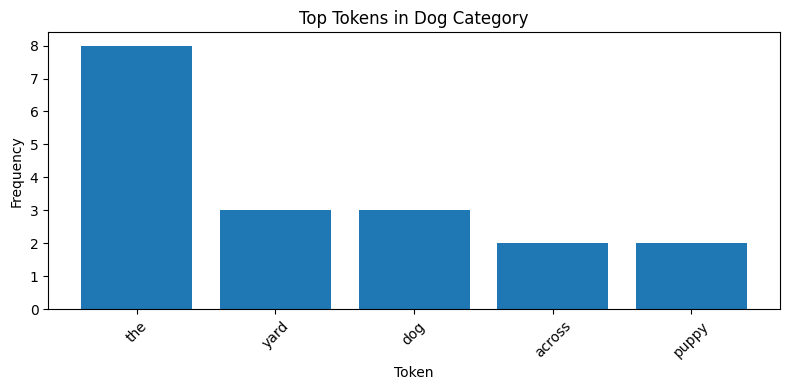

In [15]:
# Section 14 Python cell

print("IMPORTANT: Close each chart window to continue execution.")

dog_df = category_freq_df.filter(pl.col("category") == "dog").head(5)

plt.figure(figsize=(8, 4))
plt.bar(dog_df["token"], dog_df["len"])
ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)
plt.title("Top Tokens in Dog Category")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Section 15. Visual 2 - Total Tokens by Category

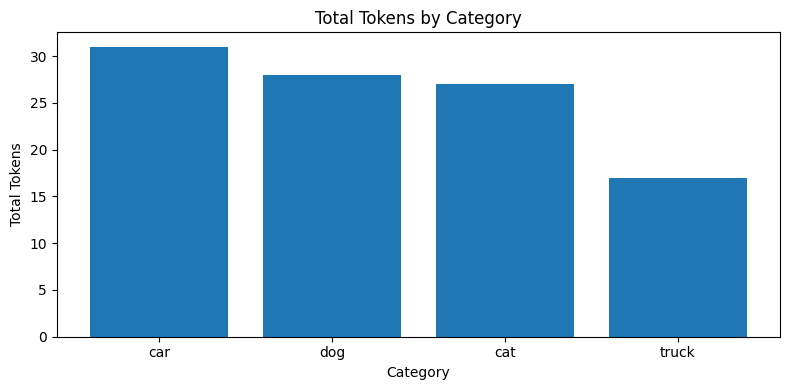

In [16]:
# Section 15 Python cell

plt.figure(figsize=(8, 4))
plt.bar(category_token_totals_df["category"], category_token_totals_df["len"])
plt.title("Total Tokens by Category")
plt.xlabel("Category")
plt.ylabel("Total Tokens")
plt.tight_layout()
plt.show()

## Section 16. Visual 3 - Lexical Density by Category

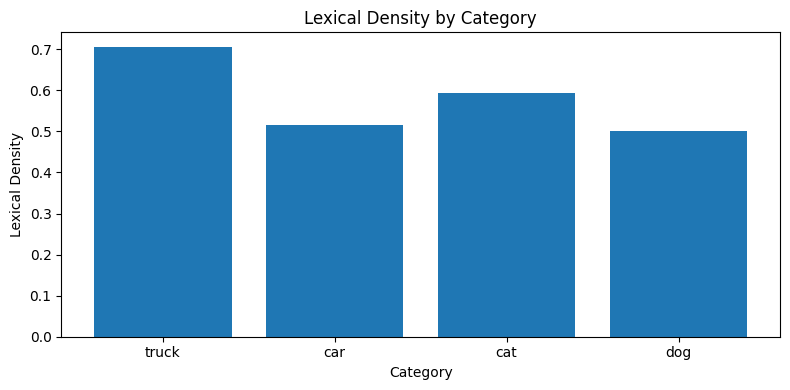

In [17]:
# Section 16 Python cell

plt.figure(figsize=(8, 4))
plt.bar(vocab_density_df["category"], vocab_density_df["lexical_density"])
plt.title("Lexical Density by Category")
plt.xlabel("Category")
plt.ylabel("Lexical Density")
plt.tight_layout()
plt.show()

## Section 17. Visual 4 - Most Common Bigrams Overall

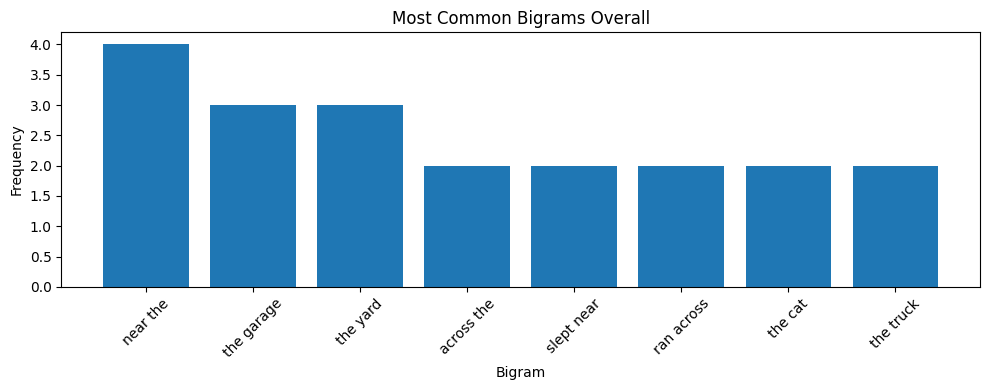

In [18]:
# Section 17 Python cell

top_bigram_plot_df = bigram_freq_df.head(8)

plt.figure(figsize=(10, 4))
plt.bar(top_bigram_plot_df["bigram"], top_bigram_plot_df["len"])
ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)
plt.title("Most Common Bigrams Overall")
plt.xlabel("Bigram")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Section 18. Visual 5 - Context Words Around Target Token

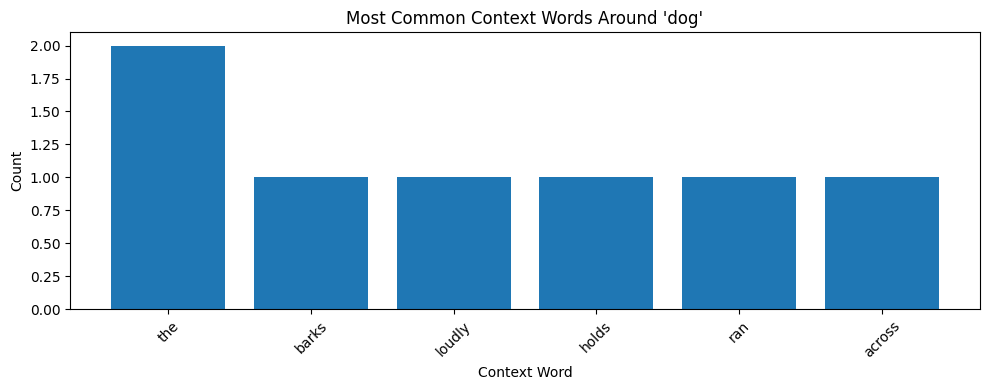

In [19]:
# Section 18 Python cell

top_context_plot_df = target_context_df.head(8)

plt.figure(figsize=(10, 4))
plt.bar(top_context_plot_df["context_word"], top_context_plot_df["count"])
ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)
plt.title(f"Most Common Context Words Around '{target_word}'")
plt.xlabel("Context Word")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [20]:
print("\nFEMI GENERAL OBSERVATIONS:")
print("- Some categories contain more total tokens than others.")
print("- Unique tokens help distinguish one category from another.")
print("- Bigrams reveal local phrase structure inside categories.")
print("- Lexical density shows how varied the vocabulary is within each category.")
print("- Context words help explain how a target token is used in nearby text.")

print("\nFEMI SPECIFIC OBSERVATIONS:")
print(
    "The dog and cat categories share some context patterns, but each still has distinct vocabulary."
)


FEMI GENERAL OBSERVATIONS:
- Some categories contain more total tokens than others.
- Unique tokens help distinguish one category from another.
- Bigrams reveal local phrase structure inside categories.
- Lexical density shows how varied the vocabulary is within each category.
- Context words help explain how a target token is used in nearby text.

FEMI SPECIFIC OBSERVATIONS:
The dog and cat categories share some context patterns, but each still has distinct vocabulary.


In [21]:
# Final Python cell

LOG.info("========================")
LOG.info("Notebook executed successfully!")
LOG.info("========================")

print("Notebook executed successfully.")

2026-03-20 19:14:20 | INFO | CI | ========================
2026-03-20 19:14:20 | INFO | CI | Notebook executed successfully!
2026-03-20 19:14:20 | INFO | CI | ========================


Notebook executed successfully.
